In [11]:
library(ggplot2)
setwd("/staging/leuven/stg_00041/Bradley/XCI.Amitesh/XISTcompaction/")

In [12]:
#the purpose of this script is to quantify DAPI intensity at XIST signal
# the input file is from imageJ, measuring signal intensity across a line
#the input is a tsv file with 3 columns, the first is the distance in microns across the cell, the second is the DAPI intensity and the third is the XIST intensity. There is an example below after I load the data

In [13]:
#function to load all files when given a folder
loadIFlineInfo <- function(folderName){
    fileNames <-list.files(path=folderName)
    lineFiles <- list()
    
    for(i in 1:length(fileNames)){
     lineFiles[[i]] <- read.table(paste(c(folderName, fileNames[i]), collapse="/"), h=T, sep="\t")  
        
    }
    
    return(lineFiles)
}


In [14]:
allDirectories <- list.dirs("/staging/leuven/stg_00041/Bradley/XCI.Amitesh/DAPIcompaction/")[-1]

In [15]:
allDirectories

[1] "/staging/leuven/stg_00041/Bradley/XCI.Amitesh/DAPIcompaction//exmc" 
[2] "/staging/leuven/stg_00041/Bradley/XCI.Amitesh/DAPIcompaction//naive"
[3] "/staging/leuven/stg_00041/Bradley/XCI.Amitesh/DAPIcompaction//TSC"

In [16]:
allData <- vector(mode="list", length=length(allDirectories))
for(i in 1:length(allData)){
 allData[[i]] <- list(folder=allDirectories[i], files=loadIFlineInfo(allDirectories[i]))   
}


In [26]:
head(allData[[i]]$files[[1]]) #showing an example of the input

,Distance_.microns.,DAPI,XIST
,<dbl>,<dbl>,<dbl>
1,0.0000,603.000,149.000
2,0.2082,325.239,165.075
3,0.4164,368.331,168.943
4,0.6246,519.098,191.715
5,0.8327,877.284,340.831
6,1.0409,1789.093,681.073


In [17]:
calculateColIntensities <- function(inputFrame, colOfPeak=3, colOfCompare=2, widthOfPeaks=1, widthOutsidePeaks=2){
    inputFrame <- inputFrame[c(-1:-2, -nrow(inputFrame):-(nrow(inputFrame)-1)),]
    peakLoc <- inputFrame[which.max(inputFrame[,colOfPeak]),1]
    peakMax <- max(inputFrame[,colOfPeak])
    SDlow <- sd(inputFrame[((inputFrame[,1]<peakLoc-widthOutsidePeaks |  inputFrame[,1]>peakLoc+widthOutsidePeaks) & inputFrame[,colOfPeak]<0.60*peakMax),colOfCompare])
    aveLow <- mean(inputFrame[((inputFrame[,1]<peakLoc-widthOutsidePeaks |  inputFrame[,1]>peakLoc+widthOutsidePeaks)& inputFrame[,colOfPeak]<0.60*peakMax),colOfCompare])
    aveHigh <-  mean(inputFrame[((inputFrame[,1]>peakLoc-widthOfPeaks &  inputFrame[,1]<peakLoc+widthOfPeaks) & inputFrame[,colOfPeak]>0.65*peakMax),colOfCompare])
    
    
    return((aveHigh/aveLow))
}

In [18]:
allIntensities <- data.frame(cellType=NA, Intensities=NA)[0,]
for(i in 1:length(allData)){
 
    #will need to adjust the 8 if you change the directory as this is cutting off the rest of the path and only taking folder name,
    allIntensities <- rbind(allIntensities, data.frame(cellType=strsplit(allData[[i]]$folder, split="/")[[1]][9],
                                              Intensities=unlist(lapply(allData[[i]]$files, calculateColIntensities, widthOfPeaks=0.5, widthOutsidePeaks=1))))
}


In [19]:
allIntensities$cellType <- factor(allIntensities$cellType, levels=c("naive", "exmc", "TSC"))
levels(allIntensities$cellType) <- c("Naive","EXMC","TSC")

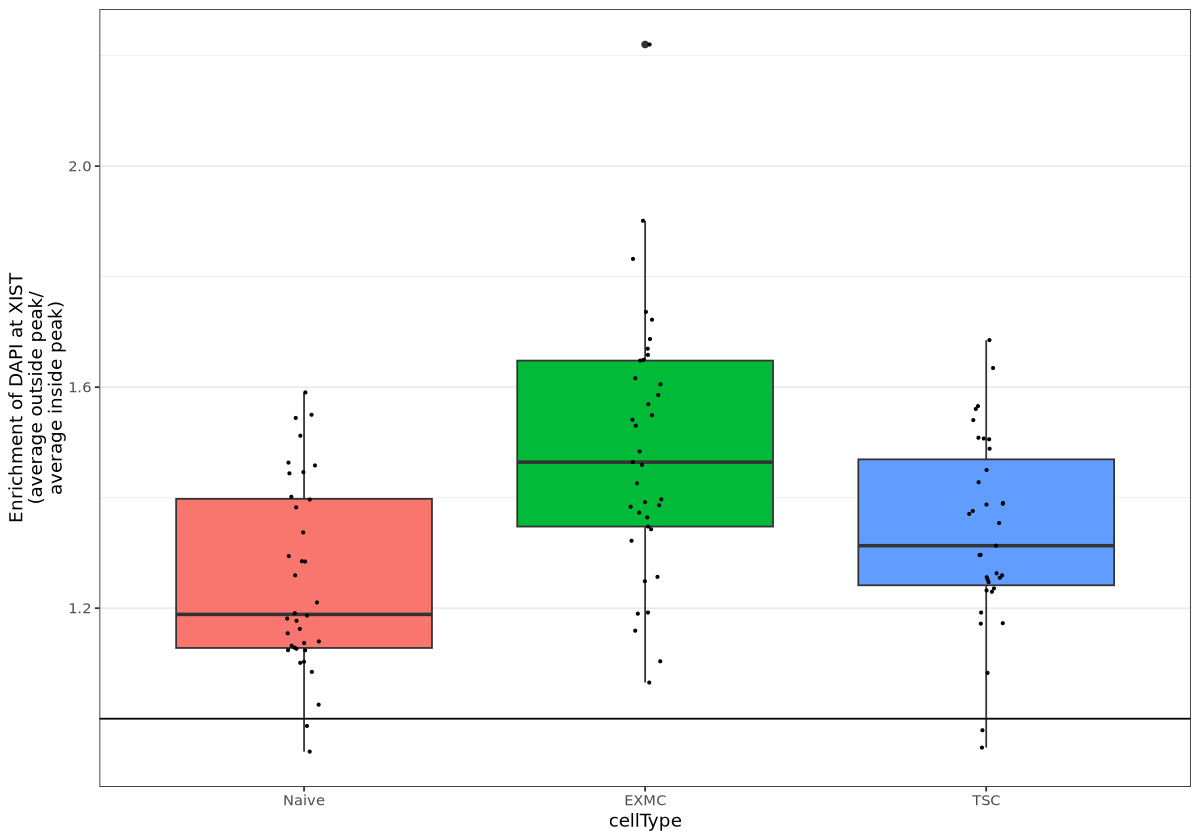

In [20]:
options(repr.plot.width=10) #this is the figure used in the revisions. You can uncomment the lines below to generate a pdf instead of outputting the image to the notebook
#pdf("/data/leuven/343/vsc34313/jupyter_notebooks/XCI/bulkRNAseq/figs.bulkRNAseq4Amitesh/DAPIquantification.pdf", width=4, height=3)
ggplot(allIntensities, aes(x=cellType, y=Intensities, fill=cellType))+geom_boxplot(notch=F)+theme_bw()+geom_jitter(aes(), width = 0.05, size=0.5)+
ylab("Enrichment of DAPI at XIST\n(average outside peak/\naverage inside peak)")+theme(panel.grid.major.x=element_blank(), legend.position="none")+
geom_hline(yintercept = 1)
#dev.off()